In [5]:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from gauss import gauss_no_pivot_unit_diag, gauss_partial_pivot
from lu import lu_no_pivot, lu_partial_pivot

In [25]:
def solve_lu(L, U, b):
    n = len(b)

    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])

    x = np.zeros(n)
    for i in reversed(range(n)):
        x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]

    return x


def solve_lu_pivot(P, L, U, b):
    b2 = P @ b
    return solve_lu(L, U, b2)


In [ ]:
sizes = [2**i for i in range(11)]
times = {
    "gauss_no_pivot": [],
    "gauss_pivot": [],
    "lu_no_pivot": [],
    "lu_pivot": []
}
errors = {
    "gauss_no_pivot": [],
    "gauss_pivot": [],
    "lu_no_pivot": [],
    "lu_pivot": []
}
labels = {
    "gauss_no_pivot": "Gauss bez pivotingu",
    "gauss_pivot": "Gauss z pivotingiem",
    "lu_no_pivot": "LU bez pivotingu",
    "lu_pivot": "LU z pivotingiem"
}

In [29]:
for n in sizes:
    A = np.random.rand(n, n)
    x_true = np.random.rand(n)
    b = A @ x_true

    start = time()
    x = gauss_no_pivot_unit_diag(A.copy(), b.copy())
    end = time()
    times["gauss_no_pivot"].append(end - start)
    errors["gauss_no_pivot"].append(np.linalg.norm(x - x_true))
 
    start = time()
    x = gauss_partial_pivot(A.copy(), b.copy())
    end = time()
    times["gauss_pivot"].append(end - start)
    errors["gauss_pivot"].append(np.linalg.norm(x - x_true))

    start = time()
    L, U = lu_no_pivot(A.copy())
    x = solve_lu(L, U, b.copy())
    end = time()
    times["lu_no_pivot"].append(end - start)
    errors["lu_no_pivot"].append(np.linalg.norm(x - x_true))

    start = time()
    P, L, U = lu_partial_pivot(A.copy())
    x = solve_lu_pivot(P, L, U, b.copy())
    end = time()
    times["lu_pivot"].append(end - start)
    errors["lu_pivot"].append(np.linalg.norm(x - x_true))

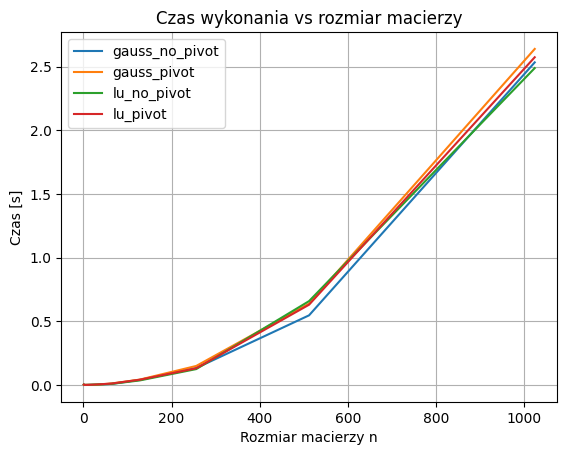

In [ ]:
plt.figure()
for key in times:
    plt.plot(sizes, times[key], label=labels[key])

plt.xlabel("Rozmiar macierzy n")
plt.ylabel("Czas [s]")
plt.title("Czas wykonania vs rozmiar macierzy")
plt.legend()
plt.grid()
plt.show()

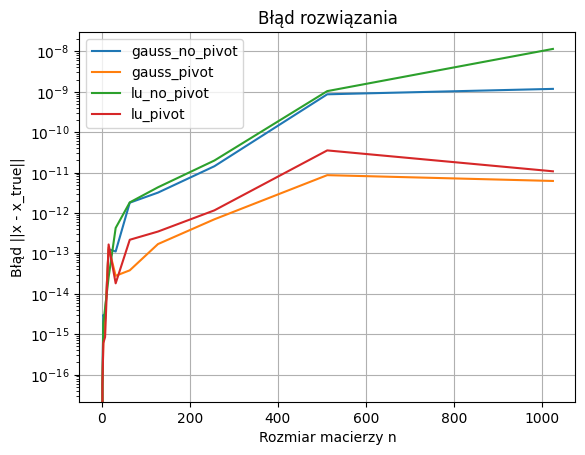

In [ ]:
plt.figure()
for key in errors:
    plt.plot(sizes, errors[key], label=labels[key])

plt.xlabel("Rozmiar macierzy n")
plt.ylabel("Błąd ||x - x_true||")
plt.yscale("log")
plt.title("Błąd rozwiązania")
plt.legend()
plt.grid()
plt.show()

In [43]:
def test(n, trials=100):
    results = {
        "gauss_no_pivot": {"time": [], "error": []},
        "gauss_pivot": {"time": [], "error": []},
        "lu_no_pivot": {"time": [], "error": []},
        "lu_pivot": {"time": [], "error": []},
    }
    for i in range(trials):
        A = np.random.rand(n, n)
        x_true = np.random.rand(n)
        b = A @ x_true

        start = time()
        x = gauss_no_pivot_unit_diag(A.copy(), b.copy())
        end = time()
        results["gauss_no_pivot"]["time"].append(end - start)
        results["gauss_no_pivot"]["error"].append(np.linalg.norm(x - x_true))
        
        start = time()
        x = gauss_partial_pivot(A.copy(), b.copy())
        end = time()

        results["gauss_pivot"]["time"].append(end - start)
        results["gauss_pivot"]["error"].append(np.linalg.norm(x - x_true))

        start = time()
        L, U = lu_no_pivot(A.copy())
        x = solve_lu(L, U, b.copy())
        end = time()
        results["lu_no_pivot"]["time"].append(end - start)
        results["lu_no_pivot"]["error"].append(np.linalg.norm(x - x_true))

        start = time()
        P, L, U = lu_partial_pivot(A.copy())
        x = solve_lu_pivot(P, L, U, b.copy())
        end = time()

        results["lu_pivot"]["time"].append(end - start)
        results["lu_pivot"]["error"].append(np.linalg.norm(x - x_true))


    A = np.random.rand(n, n)
    x_true = np.random.rand(n)
    b = A @ x_true

    print(x_true)

    start = time()
    x = gauss_no_pivot_unit_diag(A.copy(), b.copy())
    end = time()
    print(f"Gauss no pivot - result: {x}, time: {end-start}, error: {np.linalg.norm(x - x_true)}")
    print(f"Gauss no pivot - mean time: {np.mean(results['gauss_no_pivot']["time"])}, mean error - {np.mean(results['gauss_no_pivot']["error"])}")

    start = time()
    x = gauss_partial_pivot(A.copy(), b.copy())
    end = time()
    print(f"Gauss pivot - result: {x}, time: {end-start}, error: {np.linalg.norm(x - x_true)}")
    print(f"Gauss pivot - mean time: {np.mean(results['gauss_pivot']["time"])}, mean error - {np.mean(results['gauss_pivot']["error"])}")
    
    start = time()
    L, U = lu_no_pivot(A.copy())
    x = solve_lu(L, U, b.copy())
    end = time()
    print(f"LU no pivot - result: {x}, time: {end-start}, error: {np.linalg.norm(x - x_true)}")
    print(f"LU no pivot - mean time: {np.mean(results['lu_no_pivot']["time"])}, mean error - {np.mean(results['lu_no_pivot']["error"])}")
    

    start = time()
    P, L, U = lu_partial_pivot(A.copy())
    x = solve_lu_pivot(P, L, U, b.copy())
    end = time()
    print(f"LU pivot - result: {x}, time: {end-start}, error: {np.linalg.norm(x - x_true)}")
    print(f"LU pivot - mean time: {np.mean(results['lu_pivot']["time"])}, mean error - {np.mean(results['lu_pivot']["error"])}")
    

In [44]:
test(n=17)

[9.22577000e-01 3.58219481e-01 5.46294950e-02 9.50553400e-04
 4.16376049e-02 7.91019097e-01 1.71025251e-01 9.98504265e-01
 2.62580577e-01 9.38021392e-01 3.82524024e-01 9.23161469e-01
 3.21743898e-01 1.15572134e-01 3.14808270e-01 6.81663780e-01
 6.39466910e-01]
Gauss no pivot - result: [9.22577000e-01 3.58219481e-01 5.46294950e-02 9.50553400e-04
 4.16376049e-02 7.91019097e-01 1.71025251e-01 9.98504265e-01
 2.62580577e-01 9.38021392e-01 3.82524024e-01 9.23161469e-01
 3.21743898e-01 1.15572134e-01 3.14808270e-01 6.81663780e-01
 6.39466910e-01], time: 0.003785848617553711, error: 2.4939091312565067e-14
Gauss no pivot - mean time: 0.0006078100204467774, mean error - 5.385638637603354e-13
Gauss pivot - result: [9.22577000e-01 3.58219481e-01 5.46294950e-02 9.50553400e-04
 4.16376049e-02 7.91019097e-01 1.71025251e-01 9.98504265e-01
 2.62580577e-01 9.38021392e-01 3.82524024e-01 9.23161469e-01
 3.21743898e-01 1.15572134e-01 3.14808270e-01 6.81663780e-01
 6.39466910e-01], time: 0.0, error: 1.2142

In [45]:
test(n=24)

[0.94227712 0.81065444 0.28718824 0.19243659 0.55153937 0.70291974
 0.3732597  0.25465938 0.61171645 0.21068065 0.41072127 0.94888845
 0.83632478 0.92543114 0.77095641 0.55765439 0.41795985 0.6889612
 0.68779168 0.09759034 0.27694024 0.59754967 0.02845447 0.79786888]
Gauss no pivot - result: [0.94227712 0.81065444 0.28718824 0.19243659 0.55153937 0.70291974
 0.3732597  0.25465938 0.61171645 0.21068065 0.41072127 0.94888845
 0.83632478 0.92543114 0.77095641 0.55765439 0.41795985 0.6889612
 0.68779168 0.09759034 0.27694024 0.59754967 0.02845447 0.79786888], time: 0.0007245540618896484, error: 2.4110421030007344e-13
Gauss no pivot - mean time: 0.0017906618118286133, mean error - 1.4355264975884844e-12
Gauss pivot - result: [0.94227712 0.81065444 0.28718824 0.19243659 0.55153937 0.70291974
 0.3732597  0.25465938 0.61171645 0.21068065 0.41072127 0.94888845
 0.83632478 0.92543114 0.77095641 0.55765439 0.41795985 0.6889612
 0.68779168 0.09759034 0.27694024 0.59754967 0.02845447 0.79786888], t